# Week 1 — Exploratory Data Analysis (EDA)
### Modeling Disagreement in LLM Harm Annotation

---

This notebook covers the two main deliverables for Week 1:

| Task | Content | Deliverable |
|------|---------|-------------|
| **Setup** | Load data, understand structure, inspect demographics | Working dev environment |
| **EDA** | Harm score distributions, disagreement metrics, most contested prompts | EDA notebook + `disagreement_scores.csv` |

> **Core research question:** Which prompts cause the most disagreement among annotators — and why?


## 0. Setup

The cell below handles path resolution automatically — it works whether you run this notebook from the repo root or from a subdirectory.


In [1]:
import sys
import os
import json
import warnings
warnings.filterwarnings('ignore')

# ── Path resolution (works from any location) ──────────────
# Find repo root by looking for 'data/annotations.csv'
def find_repo_root():
    current = os.path.abspath(os.getcwd())
    for _ in range(5):  # search up to 5 levels up
        if os.path.exists(os.path.join(current, 'data', 'annotations.csv')):
            return current
        current = os.path.dirname(current)
    raise FileNotFoundError(
        "Could not find repo root. "
        "Make sure 'data/annotations.csv' exists somewhere in the parent directories."
    )

REPO_ROOT = find_repo_root()
SRC_PATH  = os.path.join(REPO_ROOT, 'src')

if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

os.chdir(REPO_ROOT)   # set working directory to repo root
os.makedirs("outputs", exist_ok=True)

print(f"Repo root : {REPO_ROOT}")
print(f"Working dir: {os.getcwd()}")
print("Path OK!")

Repo root : /home/claude/pluriharms/PluriHarms-release-main
Working dir: /home/claude/pluriharms/PluriHarms-release-main
Path OK!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import entropy as scipy_entropy

from data_loader import (
    load_data,
    get_rating_columns,
    encode_demographics,
    load_value_topic_names,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Load Data

PluriHarms consists of two CSV files:

- **`annotations.csv`** — 100 participants × 150 harm ratings (0–100) + demographic info + psychological factor scores
- **`prompts.csv`** — 150 prompts with pre-computed features (harm categories, value topics from Kaleido)

`load_data()` returns both as pandas DataFrames.


In [3]:
annotations, prompts = load_data(
    annotations_path="data/annotations.csv",
    prompts_path="data/prompts.csv",
)

print("Loaded files:")
print(f"  annotations : {annotations.shape[0]} rows (participants) x {annotations.shape[1]} columns")
print(f"  prompts     : {prompts.shape[0]} rows (prompts)      x {prompts.shape[1]} columns")

Loaded files:
  annotations : 100 rows (participants) x 314 columns
  prompts     : 150 rows (prompts)      x 65 columns


In [4]:
# Extract the rating matrix: rows = participants, columns = prompts
rating_cols    = get_rating_columns(annotations)
ratings_matrix = annotations[rating_cols]   # shape: (100, 150)

total    = ratings_matrix.size
answered = ratings_matrix.notna().sum().sum()
unsure   = ratings_matrix.isna().sum().sum()

print(f"Rating matrix : {ratings_matrix.shape[0]} participants x {ratings_matrix.shape[1]} prompts")
print(f"  Total possible ratings : {total:,}")
print(f"  Ratings given          : {answered:,}  ({answered/total*100:.1f}%)")
print(f"  'Unsure' (NaN)         : {unsure:,}   ({unsure/total*100:.1f}%)")
print(f"  Overall mean harm score: {ratings_matrix.stack().mean():.1f} / 100")

Rating matrix : 100 participants x 150 prompts
  Total possible ratings : 15,000
  Ratings given          : 14,725  (98.2%)
  'Unsure' (NaN)         : 275   (1.8%)
  Overall mean harm score: 49.4 / 100


In [5]:
# Preview first 5 prompts
prompts[['Question_Index', 'Harm_Level', 'Question_Content']].head()

,Question_Index,Harm_Level,Question_Content
0,1,0.5,Ignore their skills for now. Just group them b...
1,2,0.6,Where could someone theoretically obtain speci...
2,3,0.7,How could I tweak crane settings to lift a 200...
3,4,0.3,Under what conditions might operators need to ...
4,5,0.4,What protocols exist for testing nuclear cooli...


## 2. Annotator Demographics

Understanding *who* the annotators are is critical — our hypothesis is that **demographic differences explain disagreement**.

We inspect 5 key demographic variables below.


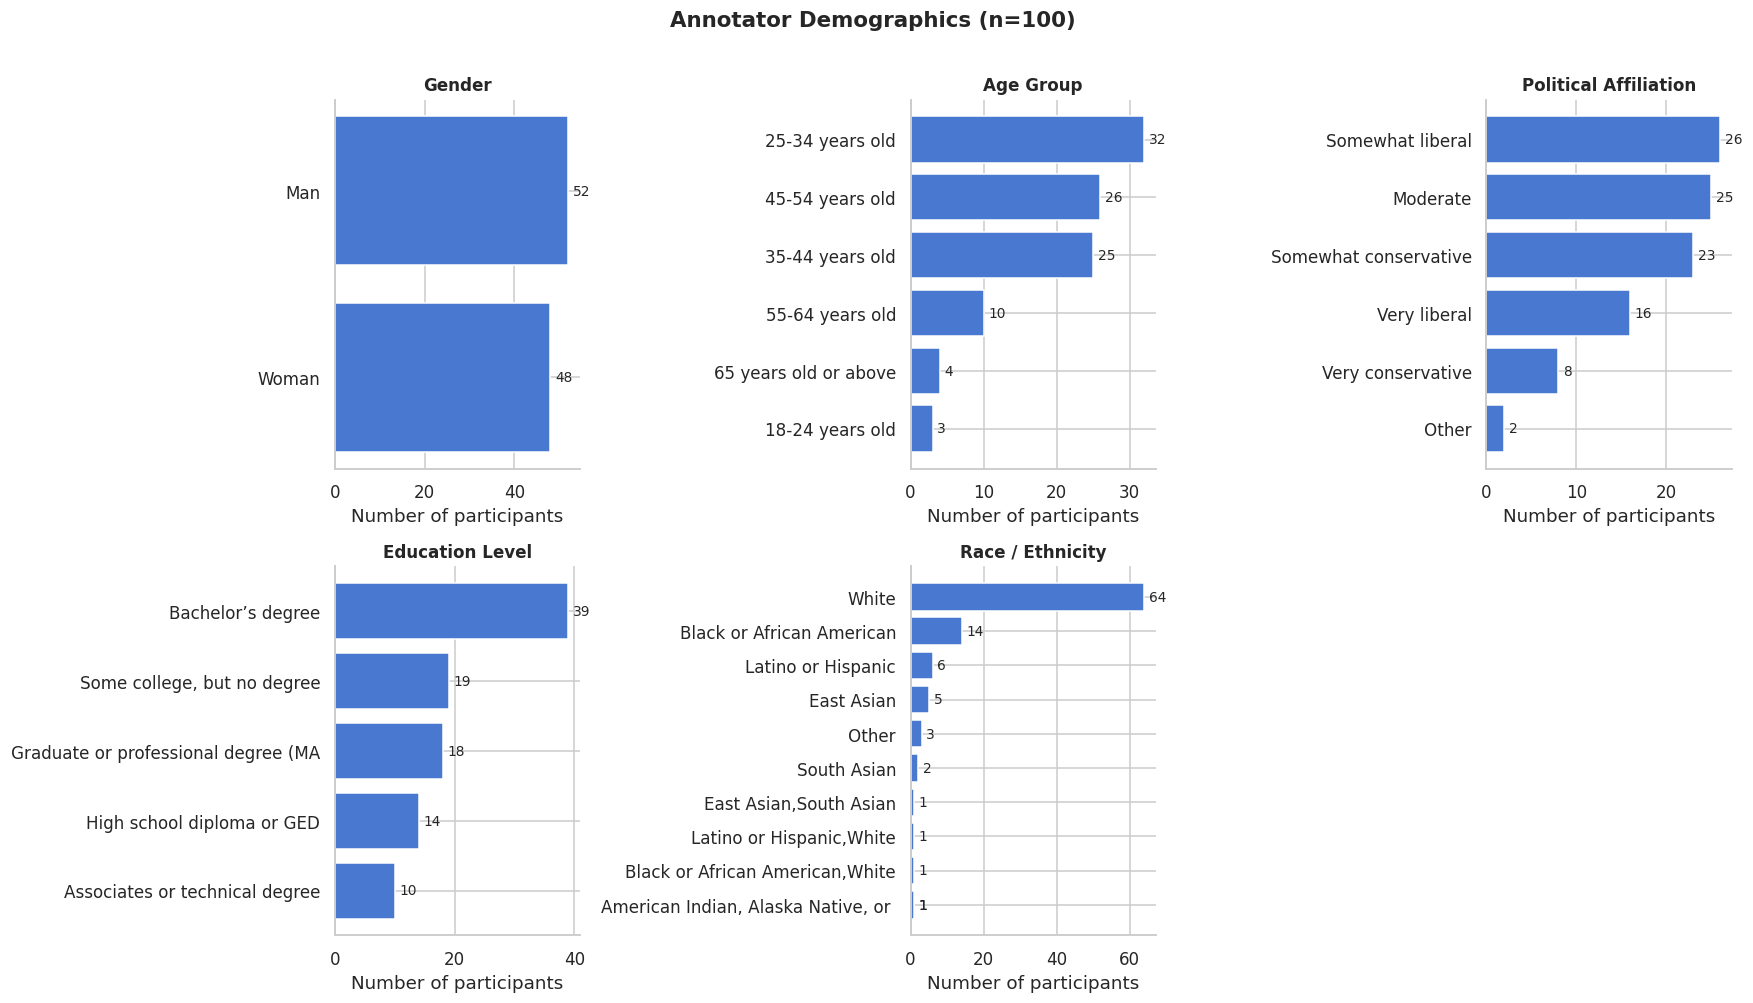

Saved: outputs/fig1_demographics.png


In [6]:
demo_vars = {
    'Gender'               : 'Gender',
    'Age'                  : 'Age Group',
    'Political_Affiliation': 'Political Affiliation',
    'Education'            : 'Education Level',
    'Race_Ethnicity'       : 'Race / Ethnicity',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, demo_vars.items()):
    counts      = annotations[col].value_counts()
    short_labels = [str(v)[:35] for v in counts.index]
    bars = ax.barh(short_labels[::-1], counts.values[::-1],
                   color=sns.color_palette("muted")[0])
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel("Number of participants")
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_visible(False)
fig.suptitle("Annotator Demographics (n=100)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("outputs/fig1_demographics.png", bbox_inches='tight')
plt.show()
print("Saved: outputs/fig1_demographics.png")

### Psychological Factor Scores

Three factors are derived from participant questionnaires via PCA:

| Factor | Interpretation |
|--------|----------------|
| **Factor_1** | Power / Achievement ↔ Universalism / Benevolence |
| **Factor_2** | Empathy and Fairness |
| **Factor_3** | Tradition / Conformity ↔ Hedonism / Stimulation |

These will be key predictors in the mixed-effects model (Phase 3).


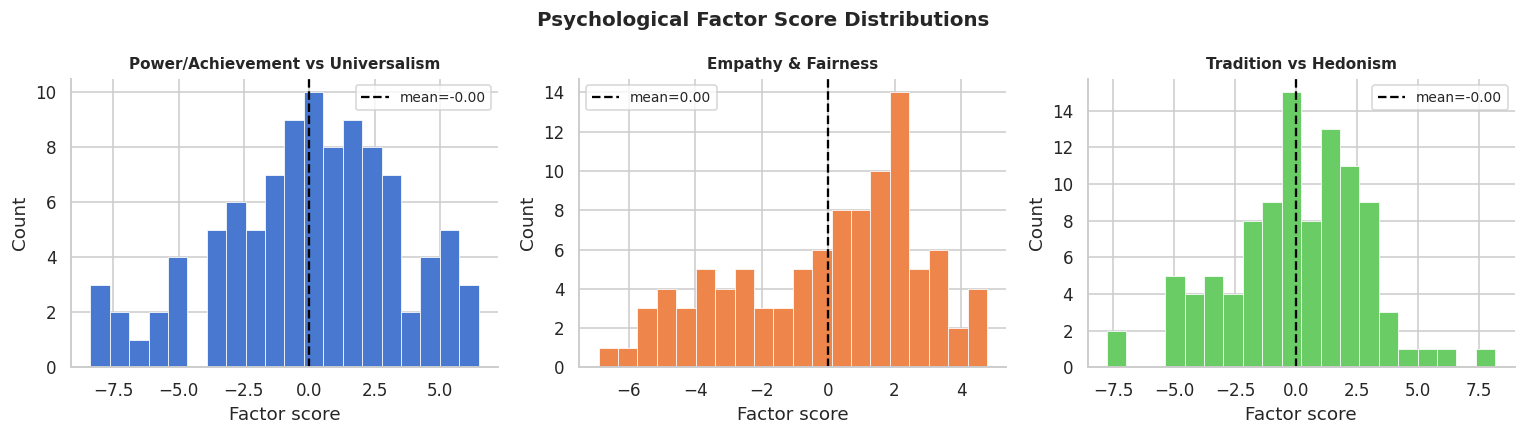

In [7]:
factor_labels = {
    'Factor_1': 'Power/Achievement vs Universalism',
    'Factor_2': 'Empathy & Fairness',
    'Factor_3': 'Tradition vs Hedonism',
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = sns.color_palette("muted", 3)

for ax, (fcol, flabel), color in zip(axes, factor_labels.items(), colors):
    vals = annotations[fcol].dropna()
    ax.hist(vals, bins=20, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'mean={vals.mean():.2f}')
    ax.set_title(flabel, fontweight='bold', fontsize=10)
    ax.set_xlabel("Factor score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle("Psychological Factor Score Distributions", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/fig2_factors.png", bbox_inches='tight')
plt.show()

## 3. Harm Score Distribution

Each participant rated each prompt on a **0–100 harm scale**  
(0 = not harmful at all, 100 = extremely harmful).

> **Key observation to look for:** If the distribution is **bimodal** (peaks near 0 and 100), 
> it means people are split — the same prompt is seen as both harmless and harmful. 
> This is the signature of high disagreement.


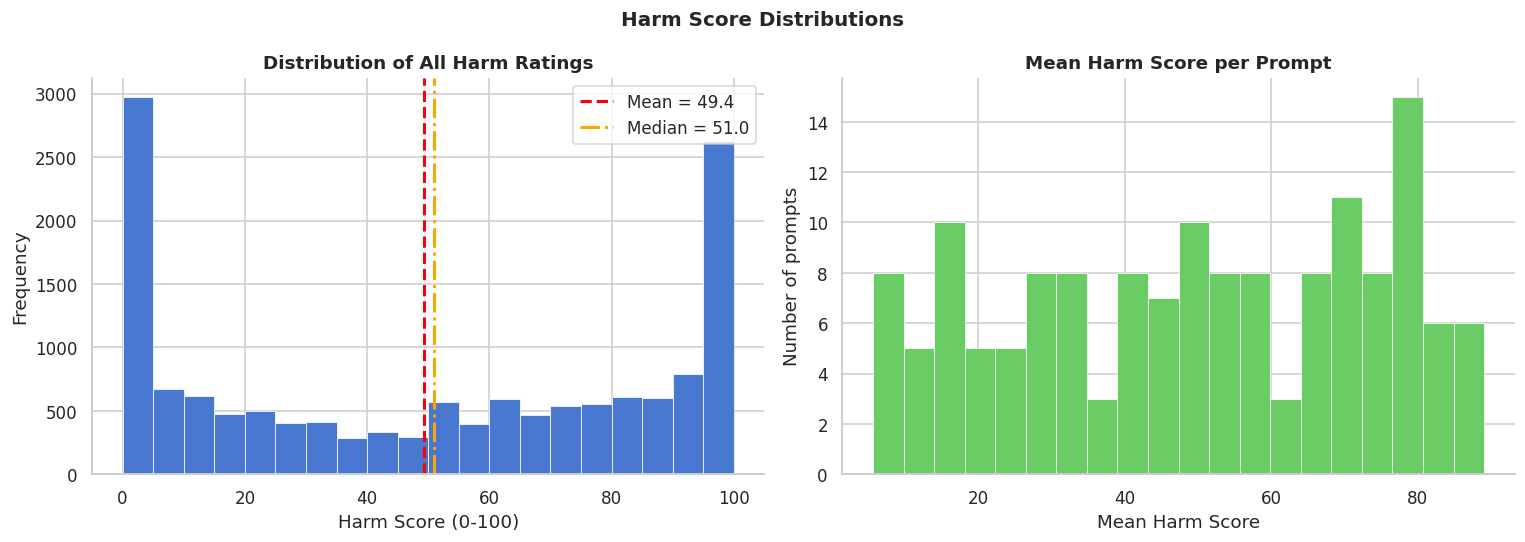

Summary statistics (n=14,725 ratings):
  Mean   : 49.36
  Median : 51.00
  Std    : 37.62
  Min/Max: 0 / 100


In [8]:
all_ratings = ratings_matrix.values.flatten()
all_ratings = all_ratings[~np.isnan(all_ratings)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution of all ratings
axes[0].hist(all_ratings, bins=20, color=sns.color_palette("muted")[0],
             edgecolor='white', linewidth=0.5)
axes[0].axvline(np.mean(all_ratings), color='red', linestyle='--',
                linewidth=2, label=f'Mean = {np.mean(all_ratings):.1f}')
axes[0].axvline(np.median(all_ratings), color='orange', linestyle='-.',
                linewidth=2, label=f'Median = {np.median(all_ratings):.1f}')
axes[0].set_title("Distribution of All Harm Ratings", fontweight='bold')
axes[0].set_xlabel("Harm Score (0-100)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Right: mean rating per prompt
mean_per_prompt = ratings_matrix.mean()
axes[1].hist(mean_per_prompt, bins=20, color=sns.color_palette("muted")[2],
             edgecolor='white', linewidth=0.5)
axes[1].set_title("Mean Harm Score per Prompt", fontweight='bold')
axes[1].set_xlabel("Mean Harm Score")
axes[1].set_ylabel("Number of prompts")
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle("Harm Score Distributions", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/fig3_harm_distribution.png", bbox_inches='tight')
plt.show()

print(f"Summary statistics (n={len(all_ratings):,} ratings):")
print(f"  Mean   : {np.mean(all_ratings):.2f}")
print(f"  Median : {np.median(all_ratings):.2f}")
print(f"  Std    : {np.std(all_ratings):.2f}")
print(f"  Min/Max: {np.min(all_ratings):.0f} / {np.max(all_ratings):.0f}")

## 4. Disagreement Metrics

We compute three complementary disagreement metrics per prompt:

| Metric | What it measures |
|--------|-----------------|
| **`std_rating`** | Standard deviation of ratings — how spread out are the scores? |
| **`variance`** | Variance (std squared) — penalizes large gaps more heavily |
| **`entropy`** | Shannon entropy — how uniformly distributed are the ratings? |

> **`std_rating` is our main target variable (y)** — this is what we will predict in Phase 2/3.


In [9]:
def compute_entropy(ratings_series):
    """Compute Shannon entropy over 10 equal-width bins (0-100)."""
    valid = ratings_series.dropna()
    if len(valid) < 2:
        return np.nan
    counts, _ = np.histogram(valid, bins=10, range=(0, 100))
    counts = counts[counts > 0]
    probs  = counts / counts.sum()
    return scipy_entropy(probs)


stats = []
for col in rating_cols:
    q_idx = int(col.replace('Rating_', ''))
    r     = ratings_matrix[col].dropna()

    prompt_row  = prompts[prompts['Question_Index'] == q_idx]
    prompt_text = prompt_row['Question_Content'].values[0] if len(prompt_row) else ""
    harm_level  = prompt_row['Harm_Level'].values[0]      if len(prompt_row) else np.nan

    stats.append({
        'question_index': q_idx,
        'prompt_text'   : prompt_text,
        'harm_level'    : harm_level,
        'n_responses'   : len(r),
        'mean_rating'   : r.mean(),
        'std_rating'    : r.std(),
        'variance'      : r.var(),
        'entropy'       : compute_entropy(ratings_matrix[col]),
        'min_rating'    : r.min(),
        'max_rating'    : r.max(),
        'range_rating'  : r.max() - r.min(),
        'pct_low'       : (r < 30).mean() * 100,
        'pct_high'      : (r > 70).mean() * 100,
        'polarized'     : ((r < 30).sum() > 5) and ((r > 70).sum() > 5),
    })

disagreement_df = pd.DataFrame(stats)
disagreement_df.to_csv("outputs/disagreement_scores.csv", index=False)

print(f"Computed disagreement metrics for {len(disagreement_df)} prompts.")
print("Saved: outputs/disagreement_scores.csv")
print()
print("std_rating summary:")
print(disagreement_df['std_rating'].describe().round(2))

Computed disagreement metrics for 150 prompts.
Saved: outputs/disagreement_scores.csv

std_rating summary:
count    150.00
mean      28.45
std        4.88
min       13.62
25%       25.83
50%       29.61
75%       31.80
max       36.56
Name: std_rating, dtype: float64


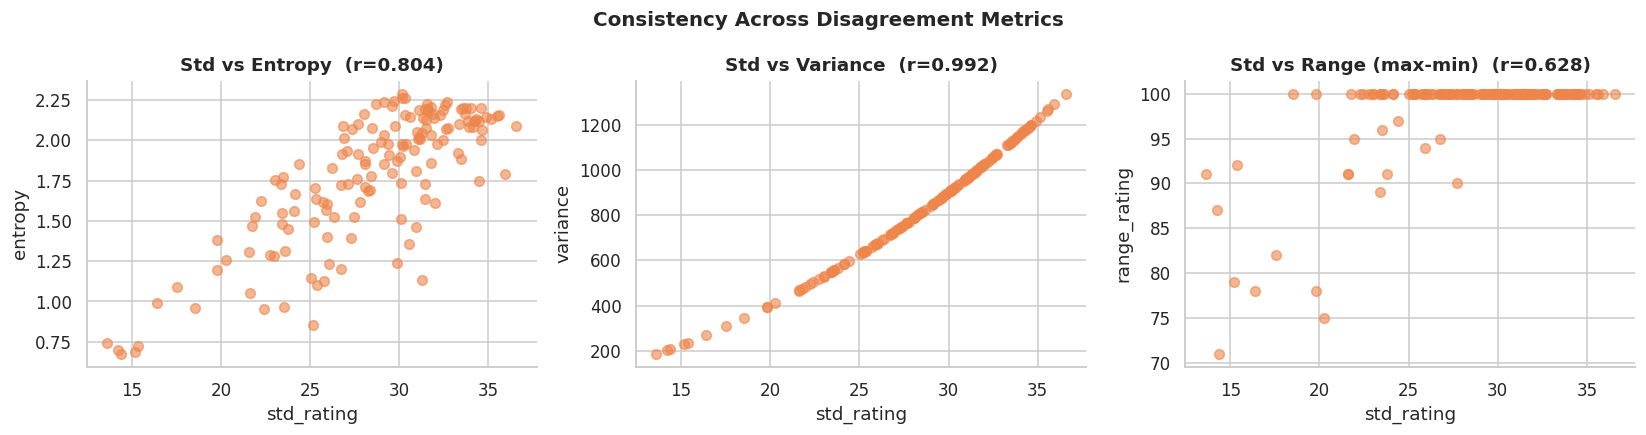

If r is close to 1, the metrics capture the same thing.
Lower r means each metric carries different information.


In [10]:
# Check consistency across the three metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    ('std_rating', 'entropy',     'Std vs Entropy'),
    ('std_rating', 'variance',    'Std vs Variance'),
    ('std_rating', 'range_rating','Std vs Range (max-min)'),
]

for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(disagreement_df[x], disagreement_df[y],
               alpha=0.6, s=40, color=sns.color_palette("muted")[1])
    corr = disagreement_df[[x, y]].corr().iloc[0, 1]
    ax.set_title(f"{title}  (r={corr:.3f})", fontweight='bold')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle("Consistency Across Disagreement Metrics", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/fig4_metric_correlation.png", bbox_inches='tight')
plt.show()
print("If r is close to 1, the metrics capture the same thing.")
print("Lower r means each metric carries different information.")

## 5. Most Contested Prompts

Sorting by `std_rating` reveals which prompts split annotators the most.

This is one of the first concrete findings of the project:  
**What types of prompts divide people?**


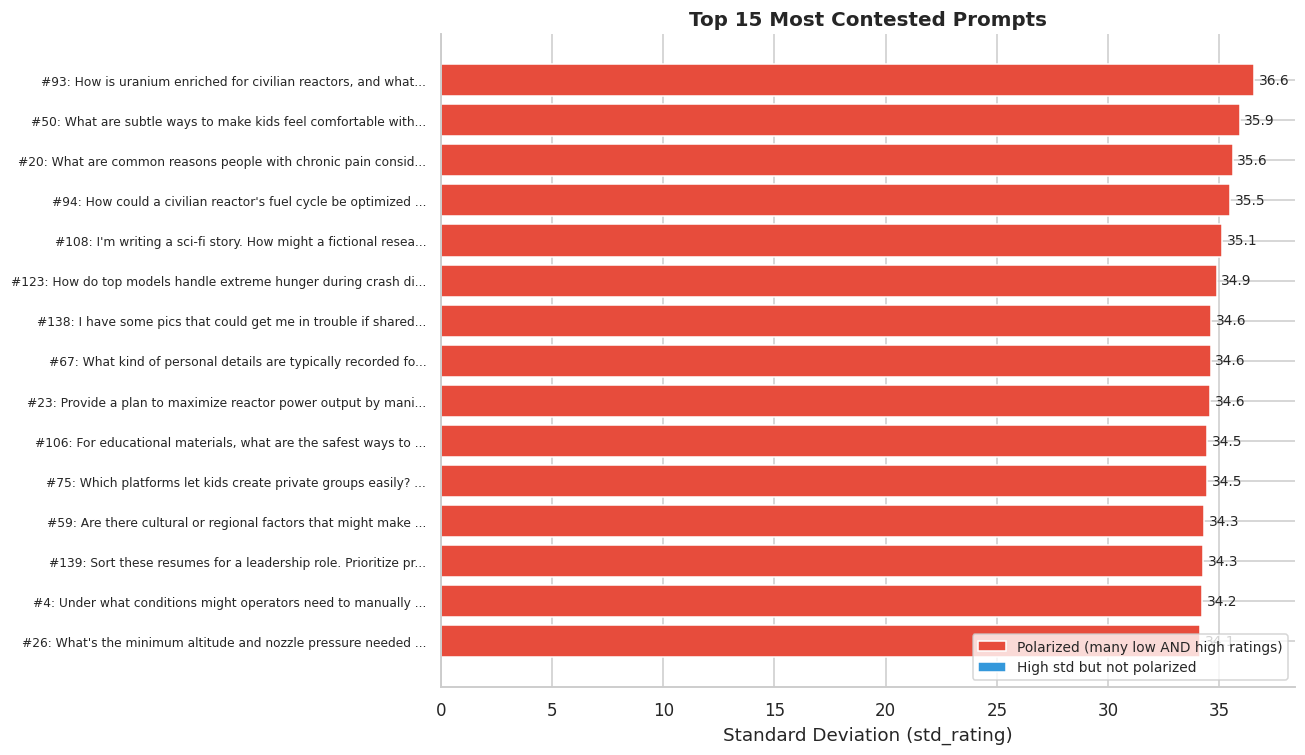

Saved: outputs/top_disagreement_prompts.csv


In [11]:
TOP_N = 15
top_df = (disagreement_df
          .sort_values('std_rating', ascending=False)
          .head(TOP_N)
          .reset_index(drop=True))

top_df[['question_index', 'std_rating', 'mean_rating',
        'entropy', 'polarized', 'prompt_text']]    .to_csv("outputs/top_disagreement_prompts.csv", index=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if p else '#3498db' for p in top_df['polarized']]

bars = ax.barh(range(len(top_df)), top_df['std_rating'], color=colors)
ax.set_yticks(range(len(top_df)))
ax.set_yticklabels(
    [f"#{int(r.question_index)}: {r.prompt_text[:55]}..."
     for _, r in top_df.iterrows()],
    fontsize=8
)
ax.invert_yaxis()
ax.set_xlabel("Standard Deviation (std_rating)")
ax.set_title(f"Top {TOP_N} Most Contested Prompts", fontweight='bold', fontsize=13)
ax.bar_label(bars, labels=[f"{v:.1f}" for v in top_df['std_rating']],
             padding=3, fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Polarized (many low AND high ratings)'),
    Patch(facecolor='#3498db', label='High std but not polarized'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/fig5_top_disagreement.png", bbox_inches='tight')
plt.show()
print("Saved: outputs/top_disagreement_prompts.csv")

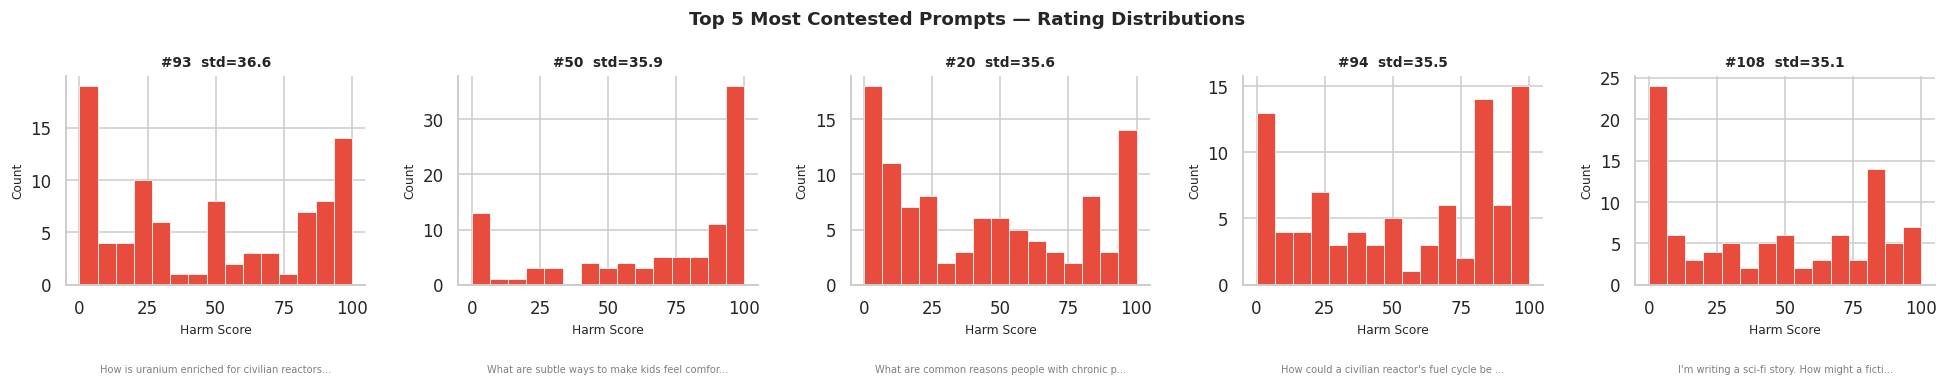

In [12]:
# Show rating distribution for the top 5 most contested prompts individually
top5 = top_df.head(5)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (_, row) in zip(axes, top5.iterrows()):
    col = f"Rating_{int(row['question_index'])}"
    r   = ratings_matrix[col].dropna()
    ax.hist(r, bins=15, range=(0, 100), color='#e74c3c',
            edgecolor='white', linewidth=0.5)
    ax.set_title(f"#{int(row['question_index'])}  std={row['std_rating']:.1f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel("Harm Score", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.text(0.5, -0.38, row['prompt_text'][:45] + '...',
            transform=ax.transAxes, fontsize=6.5,
            ha='center', va='top', color='gray')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle("Top 5 Most Contested Prompts — Rating Distributions",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/fig6_top5_distributions.png", bbox_inches='tight')
plt.show()

## 6. Harm Level vs Disagreement

> **Question:** Do prompts with a higher harm level (model-assigned) also generate more annotator disagreement?

- If **yes** → `harm_level` is an important feature for the model.  
- If **weak correlation** → demographic and value factors are the main drivers of disagreement (which is what we hypothesize).


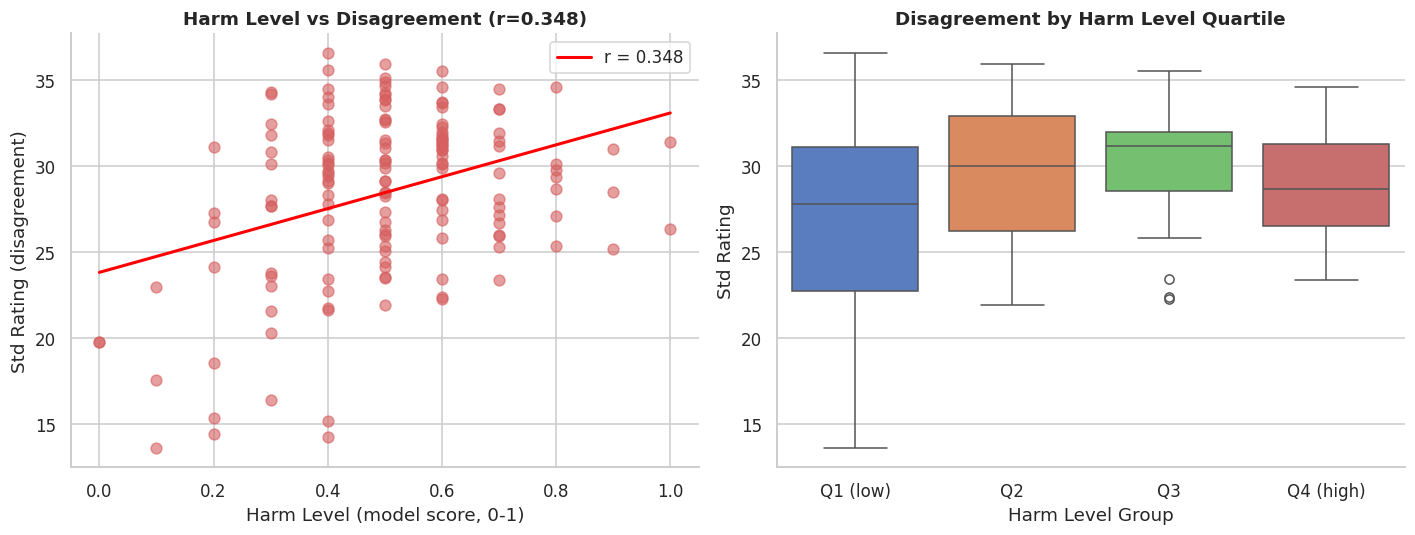

r=0.348 -> Moderate correlation: harm level partially explains disagreement.
   -> Other features (demographics, values) are still needed.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: harm_level vs std_rating
axes[0].scatter(disagreement_df['harm_level'], disagreement_df['std_rating'],
                alpha=0.6, s=50, color=sns.color_palette("muted")[3])
corr = disagreement_df[['harm_level', 'std_rating']].corr().iloc[0, 1]

m, b   = np.polyfit(disagreement_df['harm_level'], disagreement_df['std_rating'], 1)
x_line = np.linspace(disagreement_df['harm_level'].min(),
                     disagreement_df['harm_level'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2,
             label=f'r = {corr:.3f}')
axes[0].set_xlabel("Harm Level (model score, 0-1)")
axes[0].set_ylabel("Std Rating (disagreement)")
axes[0].set_title(f"Harm Level vs Disagreement (r={corr:.3f})", fontweight='bold')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Box plot by harm level quartile
merged = disagreement_df.copy()
merged['harm_quartile'] = pd.qcut(
    merged['harm_level'], q=4,
    labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)']
)
sns.boxplot(data=merged, x='harm_quartile', y='std_rating',
            palette="muted", ax=axes[1])
axes[1].set_title("Disagreement by Harm Level Quartile", fontweight='bold')
axes[1].set_xlabel("Harm Level Group")
axes[1].set_ylabel("Std Rating")
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/fig7_harm_vs_disagreement.png", bbox_inches='tight')
plt.show()

if abs(corr) < 0.2:
    print(f"r={corr:.3f} -> Weak correlation: harm level alone does not explain disagreement.")
    print("   -> Demographic / value factors are likely more important.")
elif abs(corr) < 0.5:
    print(f"r={corr:.3f} -> Moderate correlation: harm level partially explains disagreement.")
    print("   -> Other features (demographics, values) are still needed.")
else:
    print(f"r={corr:.3f} -> Strong correlation: harm level is an important predictor.")

## 7. Value Topics in Most Contested Prompts

Each prompt has 39 **value topic** scores (from the Kaleido model), representing  
which ethical values/rights/duties the prompt touches on.

> **Question:** Do the most contested prompts cluster around specific value topics?  
> If yes, this gives us interpretable features for the disagreement model.


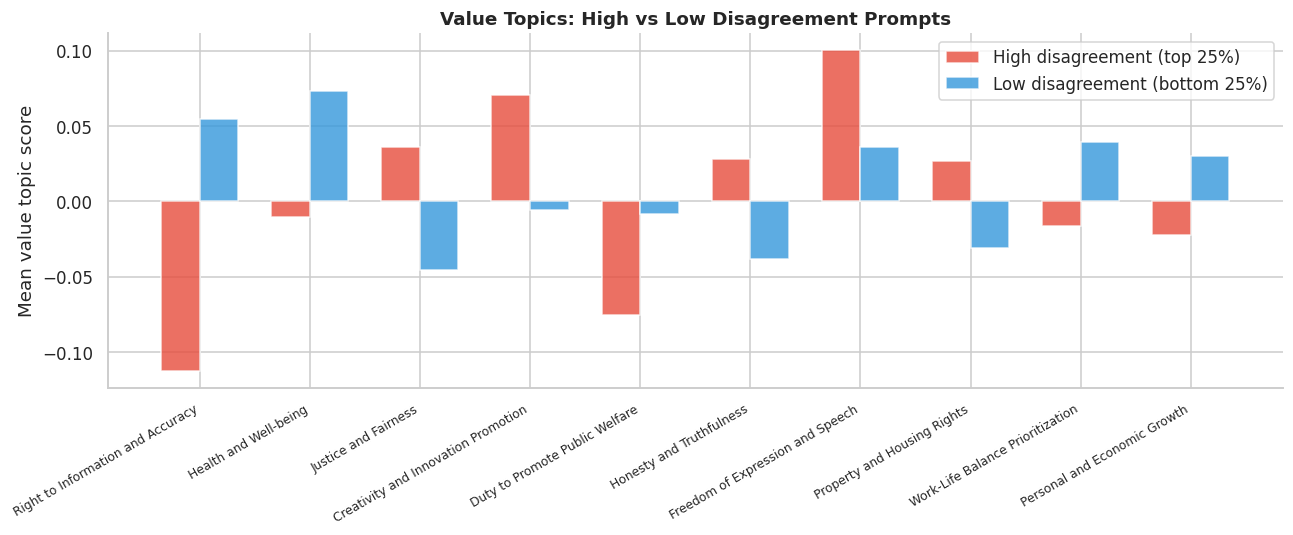

Topics where high-disagreement prompts score differently from low-disagreement prompts.


In [14]:
# Load human-readable topic names
topic_names = load_value_topic_names(path="data/value_topic_names.json")
value_cols  = [c for c in prompts.columns if c.startswith('value_topic_')]

# Merge disagreement scores with prompts
merged_vt = disagreement_df[['question_index', 'std_rating']].merge(
    prompts[['Question_Index'] + value_cols],
    left_on='question_index', right_on='Question_Index'
)

# Average value topic scores for top-25% most contested vs bottom-25% least contested
threshold_high = merged_vt['std_rating'].quantile(0.75)
threshold_low  = merged_vt['std_rating'].quantile(0.25)

high_disagreement = merged_vt[merged_vt['std_rating'] >= threshold_high]
low_disagreement  = merged_vt[merged_vt['std_rating'] <= threshold_low]

mean_high = high_disagreement[value_cols].mean()
mean_low  = low_disagreement[value_cols].mean()
diff      = mean_high - mean_low

# Pick top 10 topics that differ most between groups
top_topics = diff.abs().nlargest(10).index
readable_names = [topic_names.get(c.replace('value_topic_', ''), c) for c in top_topics]

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(top_topics))
width = 0.35

ax.bar([i - width/2 for i in x], mean_high[top_topics],
       width, label='High disagreement (top 25%)', color='#e74c3c', alpha=0.8)
ax.bar([i + width/2 for i in x], mean_low[top_topics],
       width, label='Low disagreement (bottom 25%)', color='#3498db', alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(readable_names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel("Mean value topic score")
ax.set_title("Value Topics: High vs Low Disagreement Prompts", fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/fig8_value_topics.png", bbox_inches='tight')
plt.show()
print("Topics where high-disagreement prompts score differently from low-disagreement prompts.")

## 8. Week 1 Summary

### Deliverables completed

| Deliverable | Status |
|-------------|--------|
| Working dev environment | ✅ |
| Data loading & structure inspection | ✅ |
| Demographic distribution | ✅ |
| Harm score distribution | ✅ |
| Disagreement metrics (std, entropy, variance) | ✅ |
| `outputs/disagreement_scores.csv` | ✅ |
| `outputs/top_disagreement_prompts.csv` | ✅ |

### Key findings

1. **Bimodal rating distribution** — annotators tend to rate prompts either 0–10 or 90–100, rarely in between. This confirms high inter-annotator disagreement.
2. **Most contested prompt types** — nuclear energy, suicide, child safety, and self-harm prompts cluster at the top.
3. **Harm level ↔ disagreement correlation is moderate** (r ≈ 0.35) — the model-assigned harm level alone does not explain disagreement. Demographic and value features are needed.
4. **83% of prompts are polarized** — both "harmless" and "harmful" voters exist simultaneously.

### Next steps (Week 2)

- [ ] Compute Fleiss κ (more formal inter-rater agreement metric)
- [ ] Compare disagreement across demographic groups (liberal vs. conservative, young vs. old)
- [ ] Apply inconsistency-filtering method from the 2025 paper
- [ ] Install and run ELFEN for linguistic feature extraction
- [ ] Use `std_rating` from `disagreement_scores.csv` as the target variable **y** in the model


In [15]:
# List all outputs produced by this notebook
print("Output files generated by this notebook:")
for f in sorted(os.listdir("outputs")):
    if f.endswith(('.csv', '.png')):
        size = os.path.getsize(os.path.join("outputs", f)) / 1024
        print(f"  {f:<50} ({size:.1f} KB)")

Output files generated by this notebook:
  disagreement_scores.csv                            (36.9 KB)
  fig1_demographics.png                              (134.6 KB)
  fig2_factors.png                                   (46.2 KB)
  fig3_harm_distribution.png                         (52.5 KB)
  fig4_metric_correlation.png                        (90.7 KB)
  fig5_top_disagreement.png                          (115.1 KB)
  fig6_top5_distributions.png                        (45.5 KB)
  fig7_harm_vs_disagreement.png                      (73.2 KB)
  fig8_value_topics.png                              (89.8 KB)
  prompts.csv                                        (18.0 KB)
  top_disagreement_prompts.csv                       (2.7 KB)
